In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MIni project-Piyush Khndelwal/heart.csv')
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


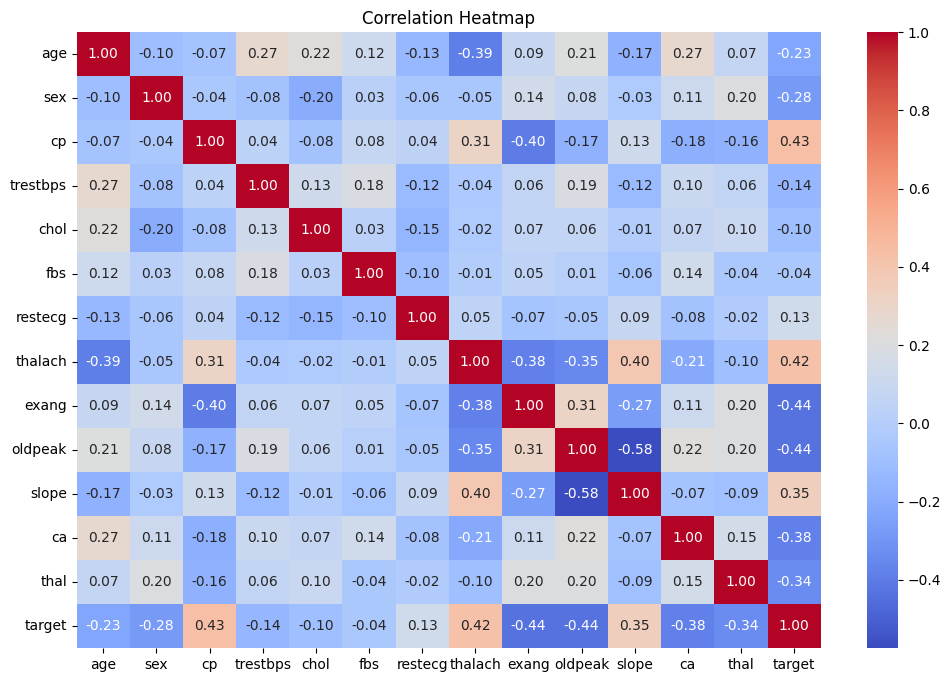

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

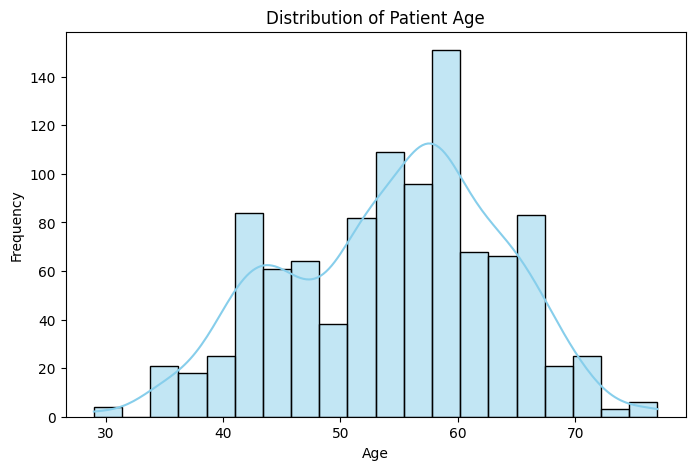

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_10429/2655262414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


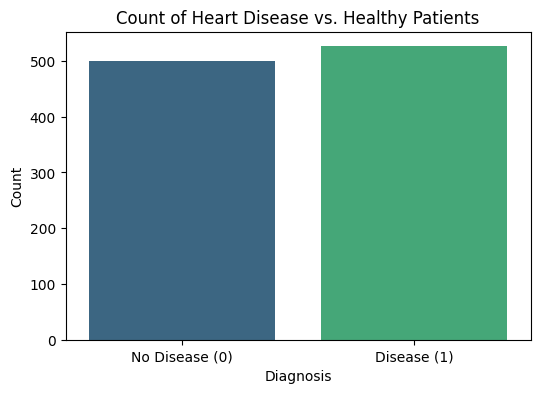

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Count of Heart Disease vs. Healthy Patients')
plt.xticks([0, 1], ['No Disease (0)', 'Disease (1)'])
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
}

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a more restricted parameter grid for Random Forest to strongly prevent overfitting
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [3, 5, 8], # Significantly restricting max_depth
    'min_samples_split': [10, 20, 30], # Increasing min_samples_split further
    'min_samples_leaf': [5, 10, 15] # Increasing min_samples_leaf further
}

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters found by GridSearchCV:", grid_search.best_params_)
print("Best ROC AUC score found by GridSearchCV:", grid_search.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters found by GridSearchCV: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 150}
Best ROC AUC score found by GridSearchCV: 0.9826162553629046



Metrics for Tuned Random Forest Model:
Accuracy: 0.9610
Precision: 0.9533
Recall: 0.9714
F1 Score: 0.9623
ROC AUC: 0.9880


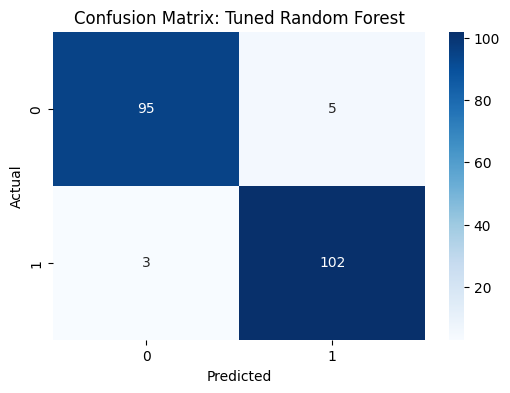

In [ ]:
# Evaluate the best model found by GridSearchCV
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate and print metrics for the tuned Random Forest model
acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"\nMetrics for Tuned Random Forest Model:")
print(f"Accuracy: {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall: {rec_tuned:.4f}")
print(f"F1 Score: {f1_tuned:.4f}")
print(f"ROC AUC: {auc_tuned:.4f}")

# Confusion Matrix for Tuned Random Forest
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, auc])


performance_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])
print(performance_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.809756   0.761905  0.914286  0.831169  0.929810
1        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
2             AdaBoost  0.887805   0.866071  0.923810  0.894009  0.957429


In [ ]:
# Create a list of the tuned Random Forest model's metrics
tuned_rf_results = ['Tuned Random Forest', acc_tuned, prec_tuned, rec_tuned, f1_tuned, auc_tuned]

# Add the tuned Random Forest results to the performance_df
performance_df.loc[len(performance_df)] = tuned_rf_results

# Display the updated performance_df
print("Updated Performance Table:")
print(performance_df)

Updated Performance Table:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.809756   0.761905  0.914286  0.831169  0.929810
1        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
2             AdaBoost  0.887805   0.866071  0.923810  0.894009  0.957429
3  Tuned Random Forest  0.960976   0.953271  0.971429  0.962264  0.988000
4  Tuned Random Forest  0.960976   0.953271  0.971429  0.962264  0.988000
5  Tuned Random Forest  0.960976   0.953271  0.971429  0.962264  0.988000
6  Tuned Random Forest  0.960976   0.953271  0.971429  0.962264  0.988000


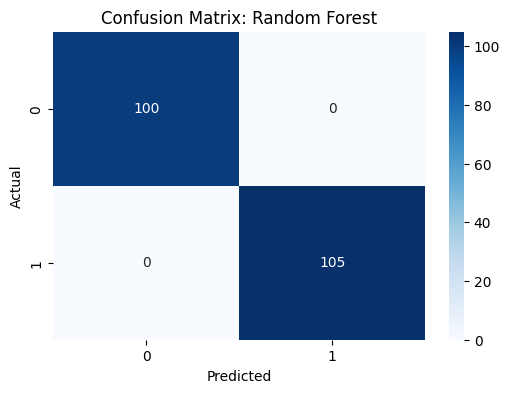

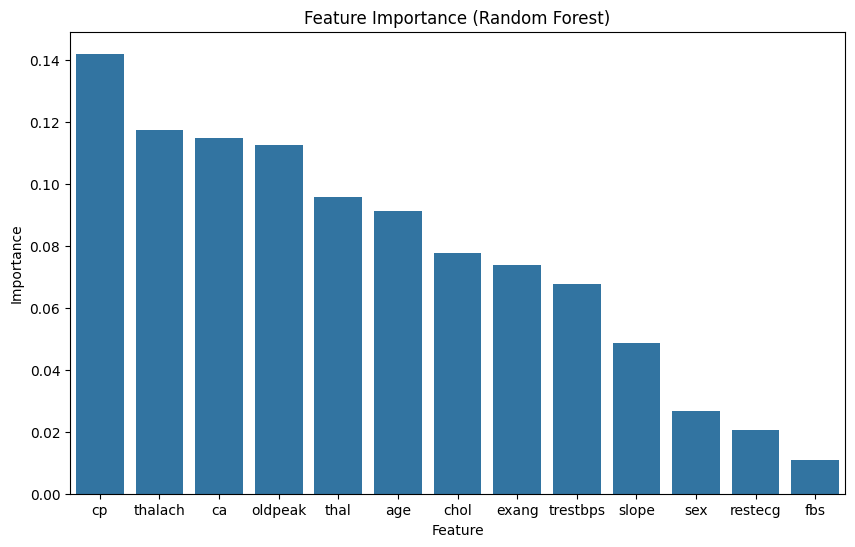

In [ ]:
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


importances = models["Random Forest"].feature_importances_
features = X.columns
feat_df = pd.DataFrame({ 'Importance': importances,'Feature': features}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Importance', data=feat_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
sample_results = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': y_pred_best[:10]
})
print(sample_results)

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       0          0
6       1          1
7       0          0
8       1          1
9       1          1


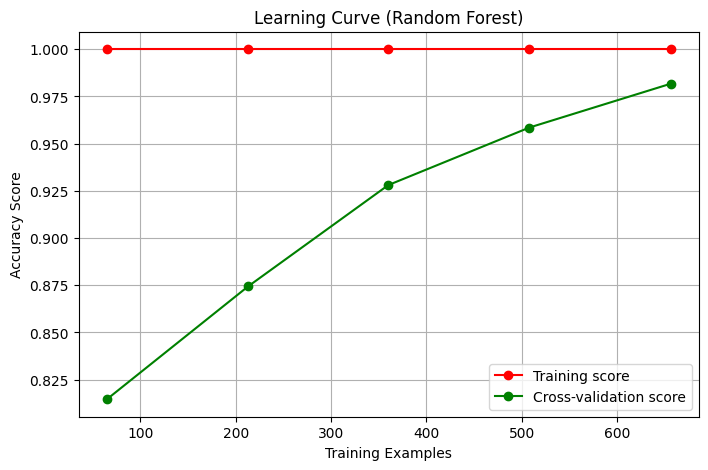

In [ ]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_learning_curve(models["Random Forest"], X_train, y_train, "Learning Curve (Random Forest)")